## Analysis of Google stock quote data since 2010

### 1. Data loading

<Axes: xlabel='Date', ylabel='Open'>

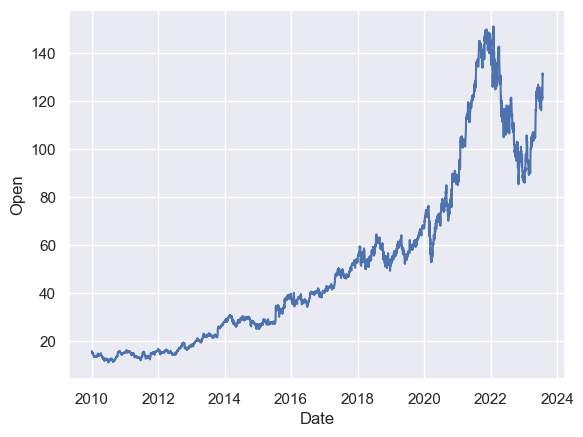

In [5]:
import pandas as pd
import seaborn as sns

google_23 = pd.read_csv('Google_Stock_Test (2023).csv')
google_10_22 = pd.read_csv('Google_Stock_Train (2010-2022).csv')

google_23['Date'] = pd.to_datetime(google_23['Date'], format='%m/%d/%Y')
google_10_22['Date'] = pd.to_datetime(google_10_22['Date'], format='%m/%d/%Y')

google = pd.concat([google_23, google_10_22]).set_index('Date').sort_index() 

sns.set_theme() 
sns.lineplot(google, x='Date', y='Open')

In [6]:
google.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2010-01-04,15.689439,15.753504,15.621622,15.684434,15.684434,78169752
2010-01-05,15.695195,15.711712,15.554054,15.615365,15.615365,120067812
2010-01-06,15.662162,15.662162,15.174174,15.221722,15.221722,158988852
2010-01-07,15.250250,15.265265,14.831081,14.867367,14.867367,256315428
2010-01-08,14.814815,15.096346,14.742492,15.065566,15.065566,188783028


### 2. Applying the seasonality processing model from the statsmodels library

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

results = seasonal_decompose(google['Open'], period=365)

#### 2.1. Seasonality display

<Axes: xlabel='Date'>

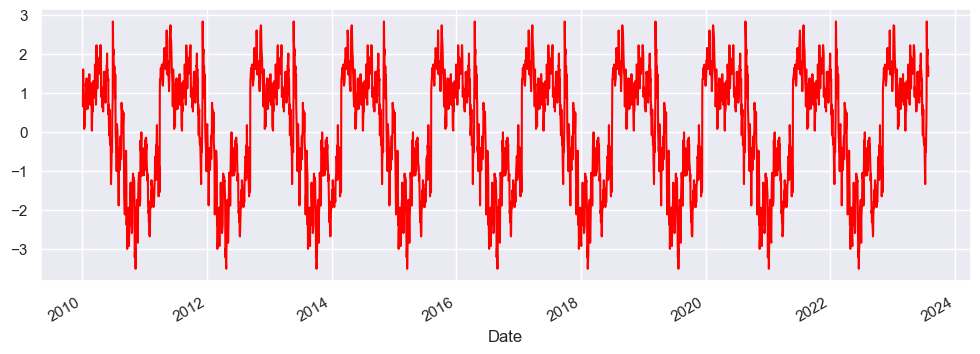

In [8]:
results.seasonal.plot(color="red", figsize=(12, 4))

#### 2.2. Clean trend

<Axes: xlabel='Date'>

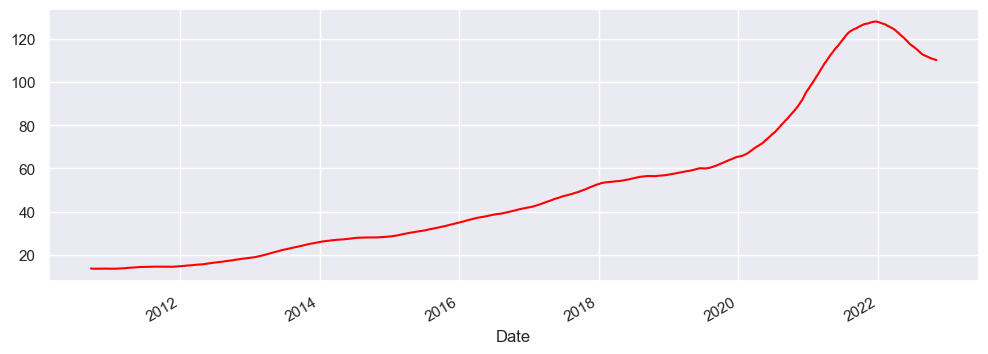

In [9]:
results.trend.plot(color="red", figsize=(12, 4))

#### 3.3. Deviation / noise

<Axes: xlabel='Date'>

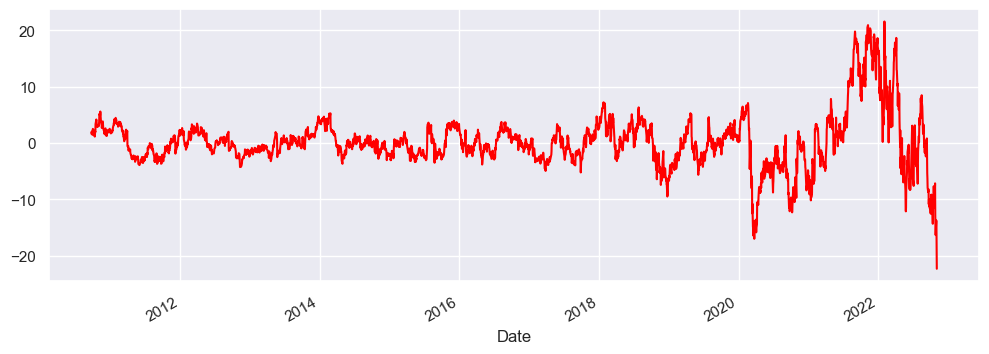

In [10]:
results.resid.plot(color="red", figsize=(12, 4))

#### 3.4. Complete decomposition

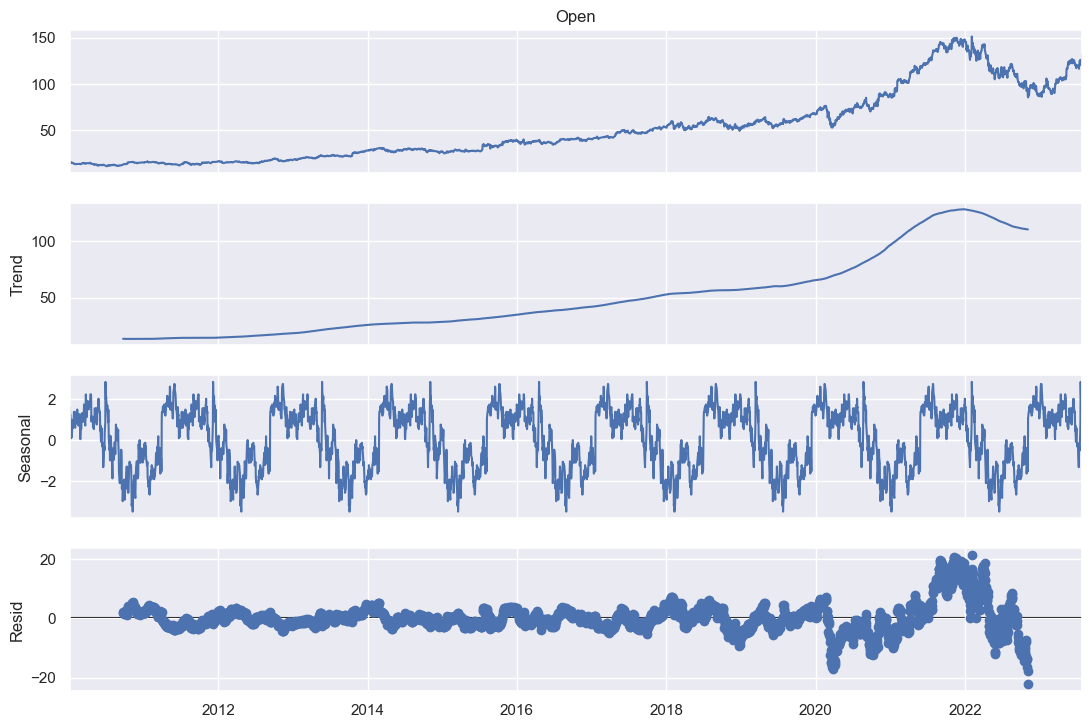

In [11]:
figure = results.plot() 

figure.set_figwidth(12) 
figure.set_figheight(8)